In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Dataset

In [2]:
# Load the training dataset
df = pd.read_csv('train.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}, Total Features: {df.shape[1]}")

Dataset Shape: (8693, 14)
Total Records: 8693, Total Features: 14


## 2. Exploratory Data Analysis (EDA)

In [3]:
# First few rows of the dataset
df.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
# Statistical summary
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [6]:
# Check missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})
print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

Missing Values Summary:
              Missing Values  Percentage (%)
CryoSleep                217        2.496261
ShoppingMall             208        2.392730
VIP                      203        2.335212
HomePlanet               201        2.312205
Name                     200        2.300702
Cabin                    199        2.289198
VRDeck                   188        2.162660
FoodCourt                183        2.105142
Spa                      183        2.105142
Destination              182        2.093639
RoomService              181        2.082135
Age                      179        2.059128


In [7]:
# Target variable distribution
print("Target Variable (Transported) Distribution:")
print(df['Transported'].value_counts())
print(f"\nPercentage Distribution:\n{df['Transported'].value_counts(normalize=True) * 100}")

Target Variable (Transported) Distribution:
Transported
True     4378
False    4315
Name: count, dtype: int64

Percentage Distribution:
Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64


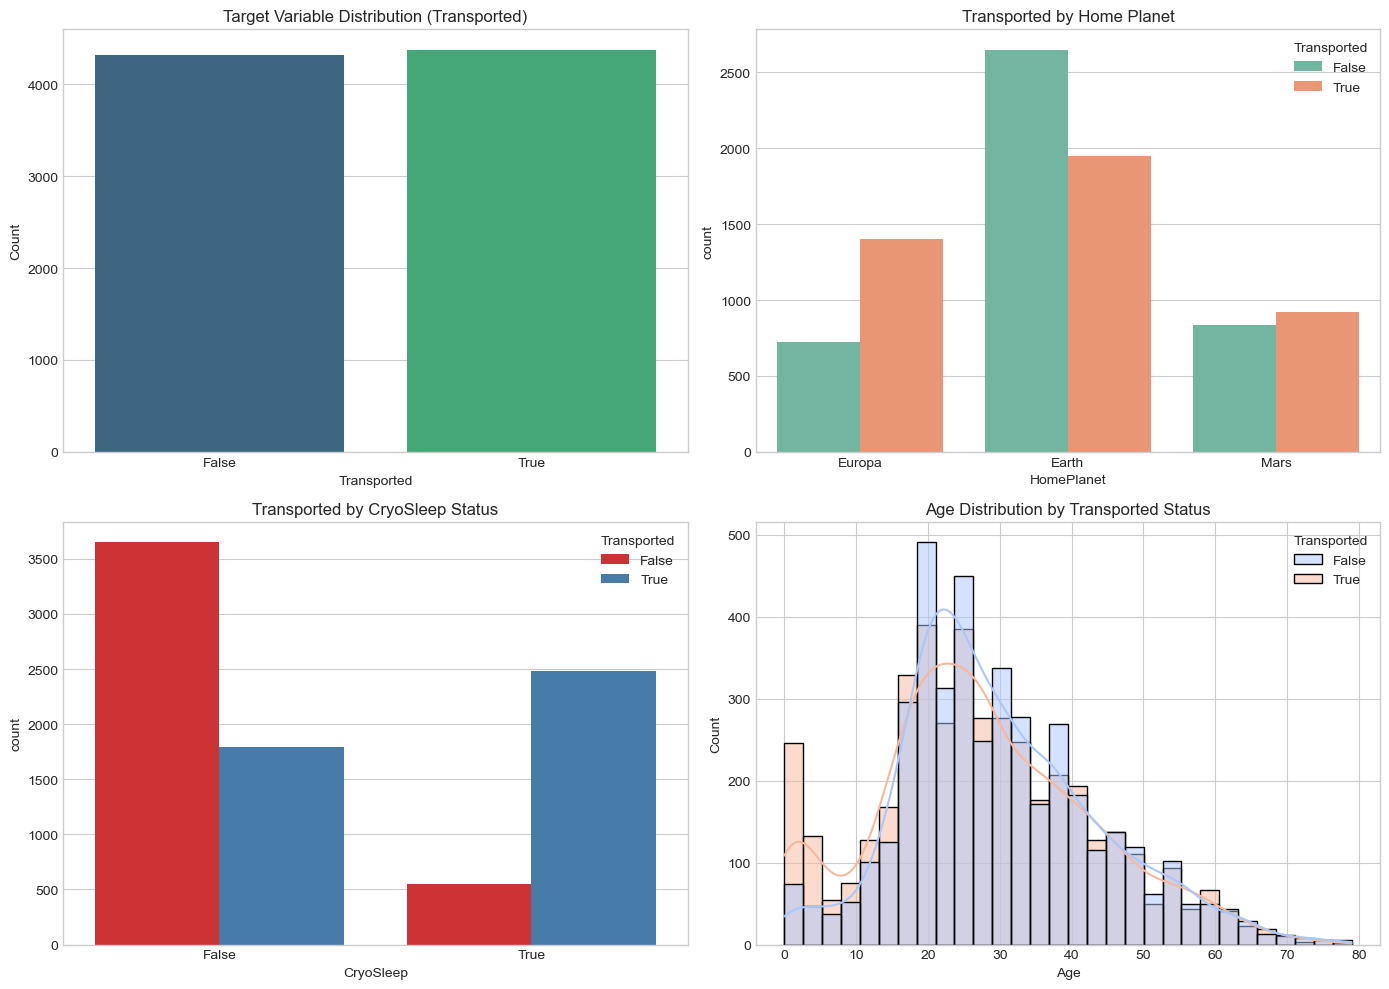

In [8]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target variable distribution (Count Plot)
sns.countplot(data=df, x='Transported', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Target Variable Distribution (Transported)')
axes[0, 0].set_xlabel('Transported')
axes[0, 0].set_ylabel('Count')

# 2. HomePlanet distribution
sns.countplot(data=df, x='HomePlanet', hue='Transported', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Transported by Home Planet')
axes[0, 1].legend(title='Transported')

# 3. CryoSleep distribution
sns.countplot(data=df, x='CryoSleep', hue='Transported', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Transported by CryoSleep Status')
axes[1, 0].legend(title='Transported')

# 4. Age distribution
sns.histplot(data=df, x='Age', hue='Transported', bins=30, ax=axes[1, 1], palette='coolwarm', kde=True)
axes[1, 1].set_title('Age Distribution by Transported Status')

plt.tight_layout()
plt.show()

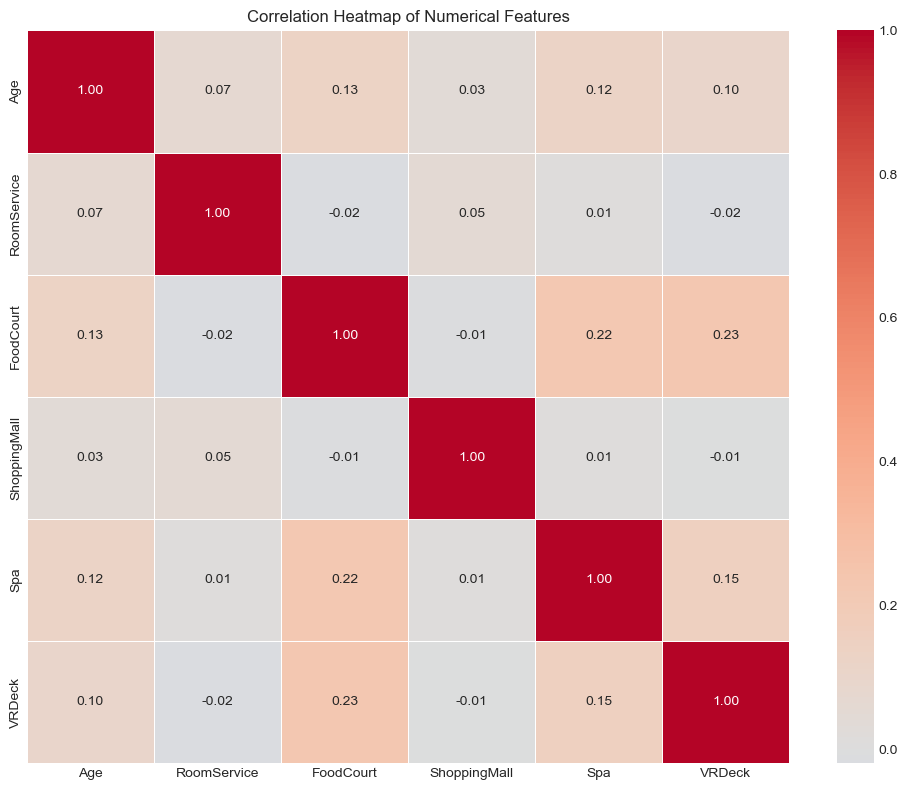

In [9]:
# Correlation Heatmap for numerical features
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [10]:
# Create a copy for preprocessing
df_processed = df.copy()

# Drop PassengerId and Name columns (not useful for prediction)
df_processed = df_processed.drop(['PassengerId', 'Name'], axis=1)

# Extract Cabin information (Deck, Number, Side)
df_processed['Deck'] = df_processed['Cabin'].apply(lambda x: x.split('/')[0] if pd.notna(x) else None)
df_processed['CabinNum'] = df_processed['Cabin'].apply(lambda x: x.split('/')[1] if pd.notna(x) else None)
df_processed['Side'] = df_processed['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) else None)
df_processed = df_processed.drop('Cabin', axis=1)

print("Columns after feature engineering:")
print(df_processed.columns.tolist())

Columns after feature engineering:
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Deck', 'CabinNum', 'Side']


In [11]:
# Handle Missing Values
# Numerical columns: fill with median
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in numerical_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# Categorical columns: fill with mode
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'CabinNum', 'Side']
for col in categorical_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

# Verify no missing values remain
print("Missing values after imputation:")
print(df_processed.isnull().sum().sum())

Missing values after imputation:
0


In [12]:
# Encode categorical variables using LabelEncoder
label_encoders = {}
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

for col in categorical_features:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le

# Convert CabinNum to numeric
df_processed['CabinNum'] = pd.to_numeric(df_processed['CabinNum'], errors='coerce')
df_processed['CabinNum'] = df_processed['CabinNum'].fillna(df_processed['CabinNum'].median())

# Encode target variable
df_processed['Transported'] = df_processed['Transported'].astype(int)

print("Data types after encoding:")
print(df_processed.dtypes)

Data types after encoding:
HomePlanet        int64
CryoSleep         int64
Destination       int64
Age             float64
VIP               int64
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Transported       int64
Deck              int64
CabinNum          int64
Side              int64
dtype: object


In [13]:
# Split features (X) and target (y)
X = df_processed.drop('Transported', axis=1)
y = df_processed['Transported']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features shape: (8693, 13)
Target shape: (8693,)

Feature columns: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Deck', 'CabinNum', 'Side']


In [14]:
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")

Training set size: 6954
Test set size: 1739
Training target distribution:
Transported
1    0.503595
0    0.496405
Name: proportion, dtype: float64


## 4. Model Training

In [15]:
# Model 1: Logistic Regression
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"\nAccuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Not Transported', 'Transported']))

MODEL 1: LOGISTIC REGRESSION

Accuracy: 0.7803 (78.03%)

Confusion Matrix:
[[669 194]
 [188 688]]

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.78      0.78      0.78       863
    Transported       0.78      0.79      0.78       876

       accuracy                           0.78      1739
      macro avg       0.78      0.78      0.78      1739
   weighted avg       0.78      0.78      0.78      1739



In [16]:
# Model 2: Random Forest Classifier
print("=" * 60)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"\nAccuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Not Transported', 'Transported']))

MODEL 2: RANDOM FOREST CLASSIFIER

Accuracy: 0.8062 (80.62%)

Confusion Matrix:
[[731 132]
 [205 671]]

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.78      0.85      0.81       863
    Transported       0.84      0.77      0.80       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



## 5. Model Comparison

Model Comparison (Before Tuning):
              Model  Accuracy
      Random Forest  0.806210
Logistic Regression  0.780334


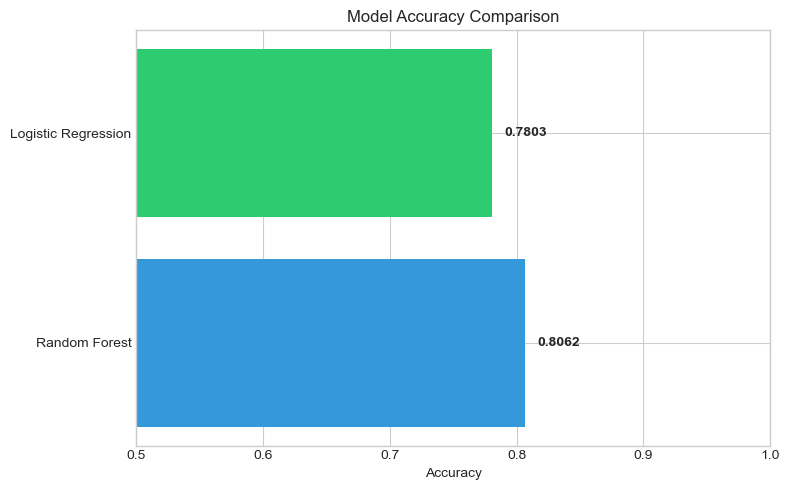

In [17]:
# Compare models before tuning
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy, rf_accuracy]
})
models_comparison = models_comparison.sort_values(by='Accuracy', ascending=False)
print("Model Comparison (Before Tuning):")
print(models_comparison.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(8, 5))
colors = ['#3498db', '#2ecc71']
plt.barh(models_comparison['Model'], models_comparison['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlim(0.5, 1.0)
for i, v in enumerate(models_comparison['Accuracy']):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning

In [18]:
# Hyperparameter Tuning for Logistic Regression using GridSearchCV
print("=" * 60)
print("HYPERPARAMETER TUNING: LOGISTIC REGRESSION")
print("=" * 60)

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)
print(f"\nBest Parameters: {lr_grid_search.best_params_}")
print(f"Best CV Score: {lr_grid_search.best_score_:.4f}")

HYPERPARAMETER TUNING: LOGISTIC REGRESSION
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Best CV Score: 0.7875


In [19]:
# Hyperparameter Tuning for Random Forest using RandomizedSearchCV
print("=" * 60)
print("HYPERPARAMETER TUNING: RANDOM FOREST")
print("=" * 60)

rf_param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random_search.fit(X_train, y_train)
print(f"\nBest Parameters: {rf_random_search.best_params_}")
print(f"Best CV Score: {rf_random_search.best_score_:.4f}")

HYPERPARAMETER TUNING: RANDOM FOREST
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}
Best CV Score: 0.8040


## 7. Final Evaluation with Tuned Models

In [20]:
# Evaluate Tuned Logistic Regression
print("=" * 60)
print("TUNED LOGISTIC REGRESSION - FINAL EVALUATION")
print("=" * 60)

lr_best_model = lr_grid_search.best_estimator_
lr_tuned_pred = lr_best_model.predict(X_test)
lr_tuned_accuracy = accuracy_score(y_test, lr_tuned_pred)

print(f"\nAccuracy: {lr_tuned_accuracy:.4f} ({lr_tuned_accuracy*100:.2f}%)")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_tuned_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_tuned_pred, target_names=['Not Transported', 'Transported']))

TUNED LOGISTIC REGRESSION - FINAL EVALUATION

Accuracy: 0.7815 (78.15%)

Confusion Matrix:
[[673 190]
 [190 686]]

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.78      0.78      0.78       863
    Transported       0.78      0.78      0.78       876

       accuracy                           0.78      1739
      macro avg       0.78      0.78      0.78      1739
   weighted avg       0.78      0.78      0.78      1739



In [21]:
# Evaluate Tuned Random Forest
print("=" * 60)
print("TUNED RANDOM FOREST - FINAL EVALUATION")
print("=" * 60)

rf_best_model = rf_random_search.best_estimator_
rf_tuned_pred = rf_best_model.predict(X_test)
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)

print(f"\nAccuracy: {rf_tuned_accuracy:.4f} ({rf_tuned_accuracy*100:.2f}%)")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_tuned_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_tuned_pred, target_names=['Not Transported', 'Transported']))

TUNED RANDOM FOREST - FINAL EVALUATION

Accuracy: 0.8114 (81.14%)

Confusion Matrix:
[[709 154]
 [174 702]]

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.80      0.82      0.81       863
    Transported       0.82      0.80      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



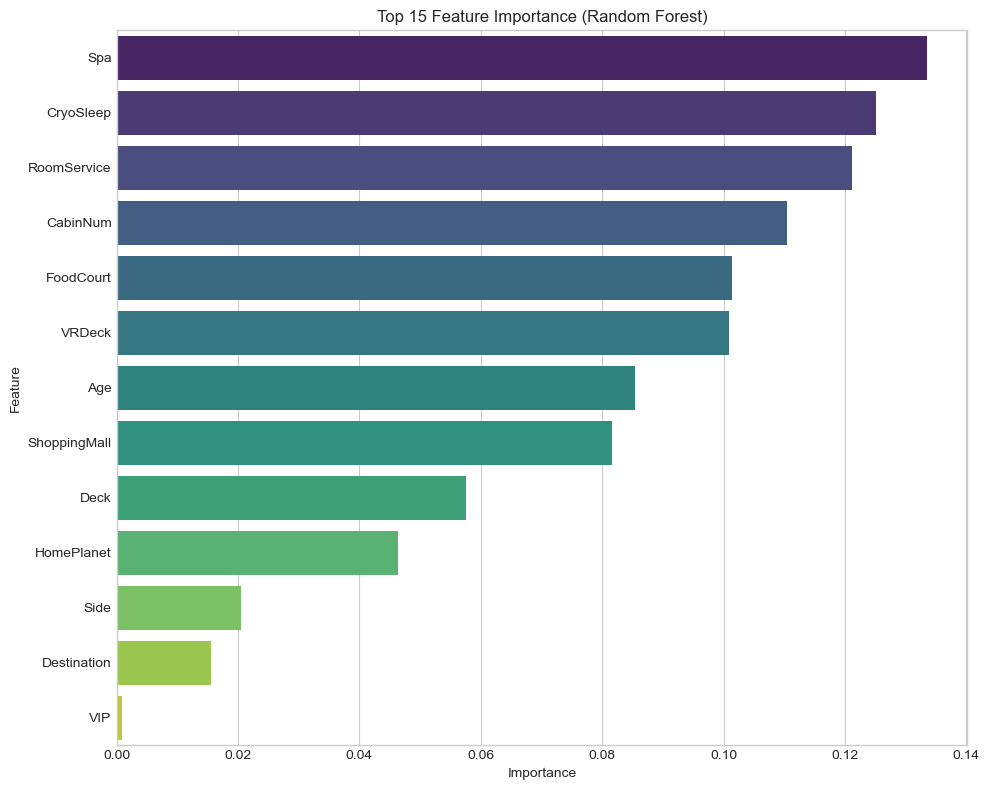


Top 10 Most Important Features:
     Feature  Importance
         Spa    0.133468
   CryoSleep    0.125044
 RoomService    0.121078
    CabinNum    0.110483
   FoodCourt    0.101341
      VRDeck    0.100847
         Age    0.085468
ShoppingMall    0.081561
        Deck    0.057503
  HomePlanet    0.046350


In [22]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

## 8. Final Summary

                    FINAL MODEL COMPARISON SUMMARY


                      Model  Accuracy
      Random Forest (Tuned)  0.811386
       Random Forest (Base)  0.806210
Logistic Regression (Tuned)  0.781484
 Logistic Regression (Base)  0.780334

BEST MODEL: Random Forest (Tuned)
BEST ACCURACY: 0.8114 (81.14%)


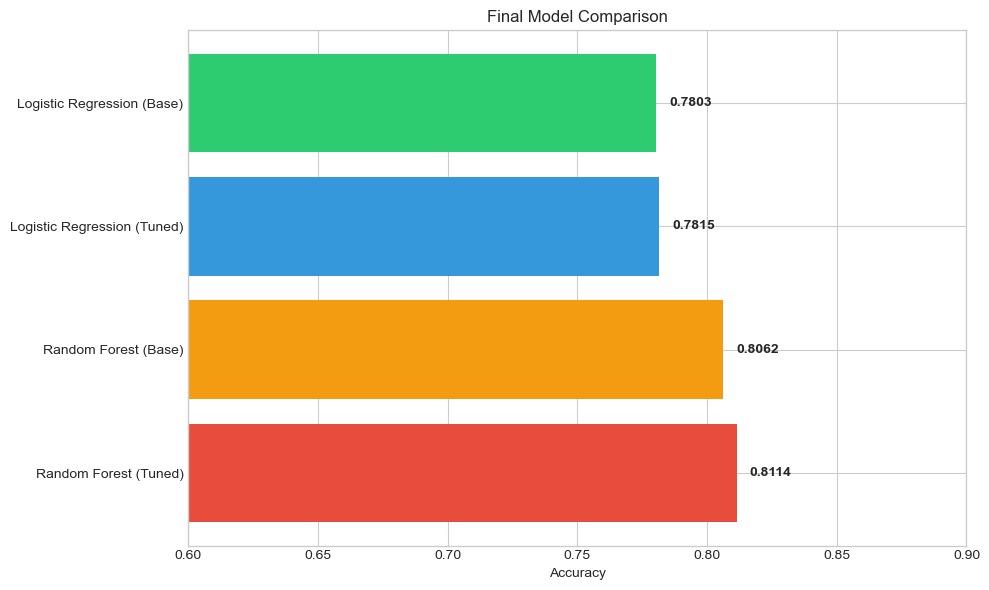

In [23]:
# Final Model Comparison Summary
print("=" * 70)
print("                    FINAL MODEL COMPARISON SUMMARY")
print("=" * 70)

final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression (Base)', 'Logistic Regression (Tuned)',
              'Random Forest (Base)', 'Random Forest (Tuned)'],
    'Accuracy': [lr_accuracy, lr_tuned_accuracy, rf_accuracy, rf_tuned_accuracy]
})
final_comparison = final_comparison.sort_values(by='Accuracy', ascending=False)
print("\n")
print(final_comparison.to_string(index=False))

# Best Model
best_model_name = final_comparison.iloc[0]['Model']
best_accuracy = final_comparison.iloc[0]['Accuracy']
print("\n" + "=" * 70)
print(f"BEST MODEL: {best_model_name}")
print(f"BEST ACCURACY: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print("=" * 70)

# Visualization
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = plt.barh(final_comparison['Model'], final_comparison['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Final Model Comparison')
plt.xlim(0.6, 0.9)
for bar, acc in zip(bars, final_comparison['Accuracy']):
    plt.text(acc + 0.005, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

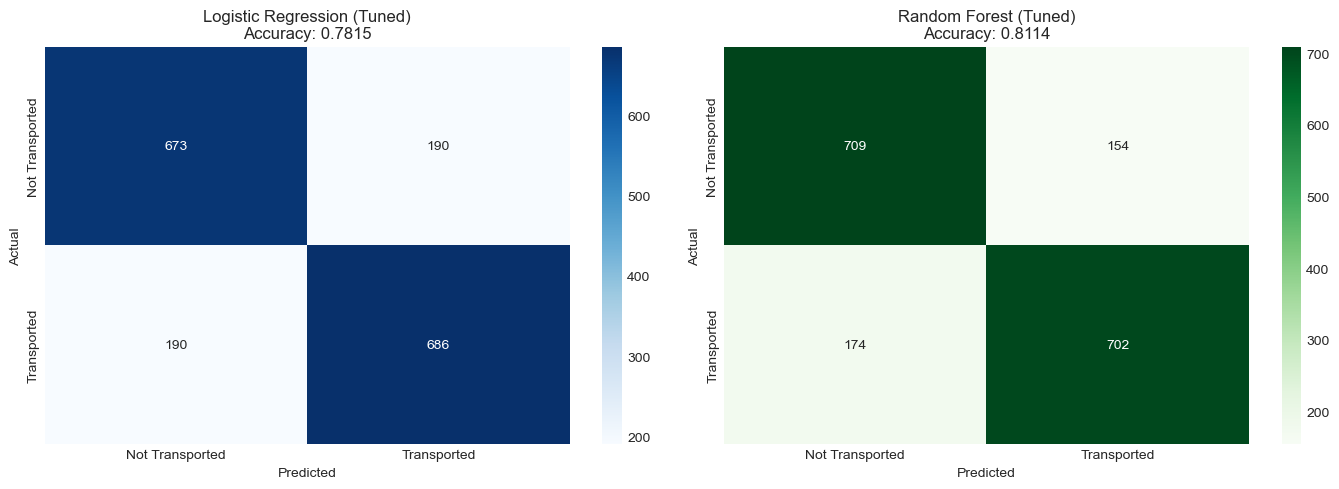


Notebook completed successfully!


In [24]:
# Confusion Matrix Visualization for Best Models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_tuned_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
axes[0].set_title(f'Logistic Regression (Tuned)\nAccuracy: {lr_tuned_accuracy:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_tuned_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
axes[1].set_title(f'Random Forest (Tuned)\nAccuracy: {rf_tuned_accuracy:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\nNotebook completed successfully!")